In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model

In [5]:
# load latent vectors and model
Z = np.load('../data/processed/Z_256.npy')
model = load_model('../models/transformers/transformer_latent_predictor_1.keras')

In [6]:
# create sequences
sequence_len = 10
X_seq = np.stack([Z[i:i+sequence_len] for i in range(len(Z) - sequence_len)])
y_true = Z[sequence_len:]

print("Input sequences:", X_seq.shape)
print("Prediction targets:", y_true.shape)

Input sequences: (9555, 10, 256)
Prediction targets: (9555, 256)


In [7]:
# make predictions
y_pred = model.predict(X_seq, batch_size=64)

# compute prediction error (MSE per sample)
errors = np.mean((y_pred - y_true)**2, axis=1)

# save errors
np.save("../data/processed/transformer_1_errors.npy", errors)

150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step


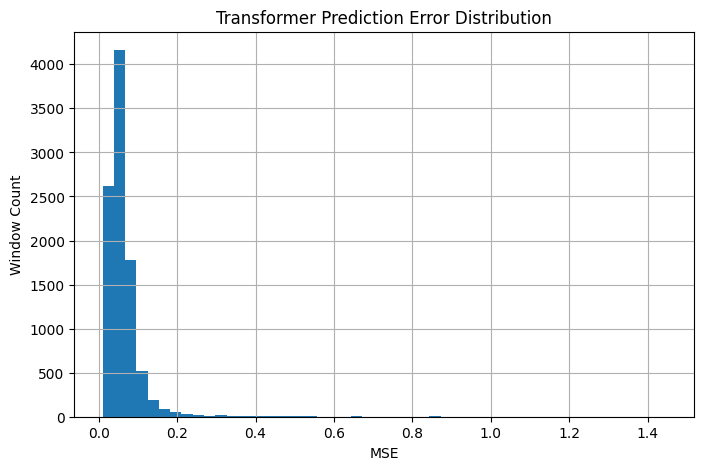

In [8]:
# plot histogram of errors
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=50)
plt.title("Transformer Prediction Error Distribution")
plt.xlabel("MSE")
plt.ylabel("Window Count")
plt.grid(True)
plt.show()

In [9]:
# identify anomalies (top 1%)
threshold = np.percentile(errors, 99)
anomaly_indices = np.where(errors > threshold)[0]

print("Top 1% anomaly threshold:", round(threshold, 4))
print("Number of anomalies:", len(anomaly_indices))

Top 1% anomaly threshold: 0.2666
Number of anomalies: 96


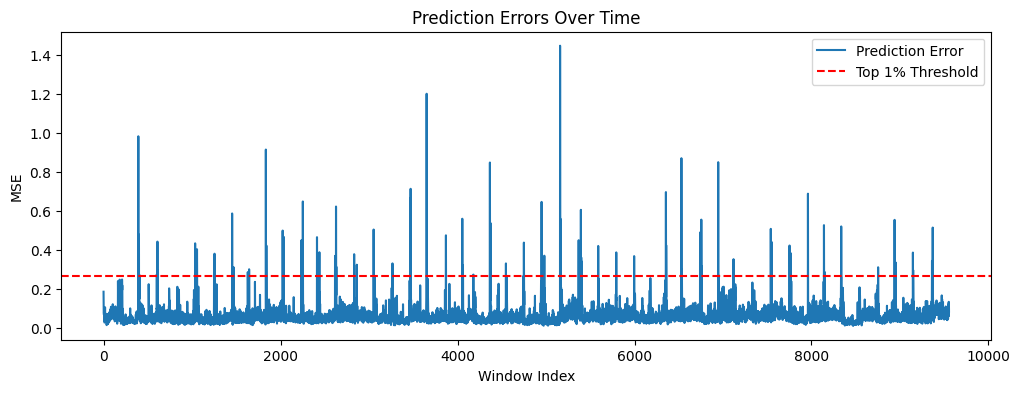

In [10]:
# plot anomaly scores over time
plt.figure(figsize=(12, 4))
plt.plot(errors, label="Prediction Error")
plt.axhline(threshold, color='red', linestyle='--', label='Top 1% Threshold')
plt.title("Prediction Errors Over Time")
plt.xlabel("Window Index")
plt.ylabel("MSE")
plt.legend()
plt.show()